# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name:



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [ ]:
## Import libraries

# Core data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Model training and evaluation
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# Saving the trained model for the Streamlit app
import joblib

# 1. Business Understanding
Goal: ?

Goal:predict whether a live shopping session will end in a purchase, so the retailer can intervene before the visitor leaves.

An online retailer takes in thousands of sessions a day, and only around 15% of them end in a purchase. The other 85% leave without buying, and the business has no signal that a visitor is slipping away until they're already gone, by then the only options are to email them later or hope they come back on their own. If the site can score a visitor's purchase intent while the session is still live, it can act on that score in the moment: surface a live chat prompt, remind them how close they are to free delivery, hold the visitor before they close the tab. This project builds that scoring model, a binary classifier that predicts whether a session will end in a purchase (Revenue), using only the behavioural signals the site already measures as the session happens, such as pages visited, time on each page type, and how the visitor arrived. Success is defined by how well the model catches the visitors who are likely to buy, because the two kinds of mistake are not equally costly: a missed buyer is a lost sale, while a visitor wrongly flagged as a buyer costs only an unnecessary prompt the visitor can ignore. That asymmetry is why the model is tuned to protect against missed buyers first.

# 2. Data Understanding

## 2.1 Load dataset

In [ ]:
##Load the dataset
df = pd.read_csv('../data/online_shoppers_intention.csv')
print(df.shape)
df.head()

(12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 2.2 Summary Statistics

In [ ]:
## Understand the type of variable for each column  
df.info()


OperatingSystems, Browser, Region, and TrafficType are stored as int64, but they're not real quantities: they're ID codes for categories (e.g. TrafficType 8 isn't "twice" TrafficType 4). Fed straight into a linear model, those numbers would imply an ordering and distance between categories that doesn't exist, so the model would learn a fake relationship from the arbitrary label numbering. They'll need one-hot encoding before modeling, the same way Month and VisitorType will.

Administrative, Informational, and ProductRelated, by contrast, are genuine counts (number of pages of that type visited in the session). Doubling the value doubles the meaning, so they stay numeric as-is.

In [7]:
## Check for missing data
print(df.isnull().sum())

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


All 18 columns report zero nulls, so no imputation or row-dropping is needed, which means no imputation bias to worry about and nothing to justify or defend in preprocessing. That said, the absence of nulls doesn't guarantee the absence of missing data, so I also checked describe() and the value counts for sentinel values disguised as data (-1, 0, 999, ?) and found none, so the zero-null result holds.

In [13]:
## Describe data distribution
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


The numeric distributions are heavily right-skewed: every mean sits above its median, with Administrative_Duration at a median of 7.5 against a mean of 80.8, and ProductRelated_Duration reaching 63,974 seconds against a median of 599. PageValues has both its median and 75th percentile at zero, so at least 75% of sessions carry no page value. The zeros are semantically real rather than missing — 0 for Administrative_Duration means no time spent on administrative pages, not an unknown value — and no -1 or 999 sentinels appear anywhere, confirming the earlier null check.

Two separate implications for modelling. Scale: features range from bounded rates in [0, 0.2] to durations in the tens of thousands, and because L2 regularisation penalises squared coefficients without regard to units, a large-scale feature escapes the penalty almost entirely while a bounded one is shrunk hard — so LogisticRegression needs StandardScaler, fitted on the training set only. Skew: standardisation rescales but doesn't reshape, so extreme sessions retain disproportionate leverage; a log transform of the duration columns is an option if the linear model underperforms. Tree-based models are unaffected by either, since splits depend on ordering rather than magnitude.

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

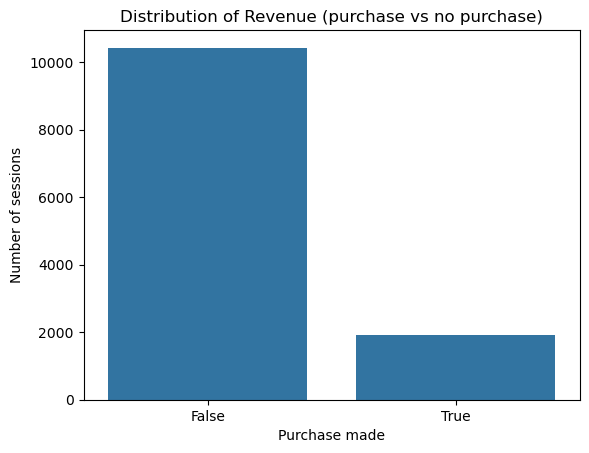

Revenue
False    0.845255
True     0.154745
Name: proportion, dtype: float64


In [17]:
## Understanding distribution of target
sns.countplot(x='Revenue', data=df)
plt.title('Distribution of Revenue (purchase vs no purchase)')
plt.xlabel('Purchase made')
plt.ylabel('Number of sessions')
plt.show()

print(df['Revenue'].value_counts(normalize=True))

15.47% of sessions end in a purchase against 84.53% that do not, confirming the class imbalance and ruling out accuracy as a primary metric.

### 2.3.1.2 Understanding distribution of features

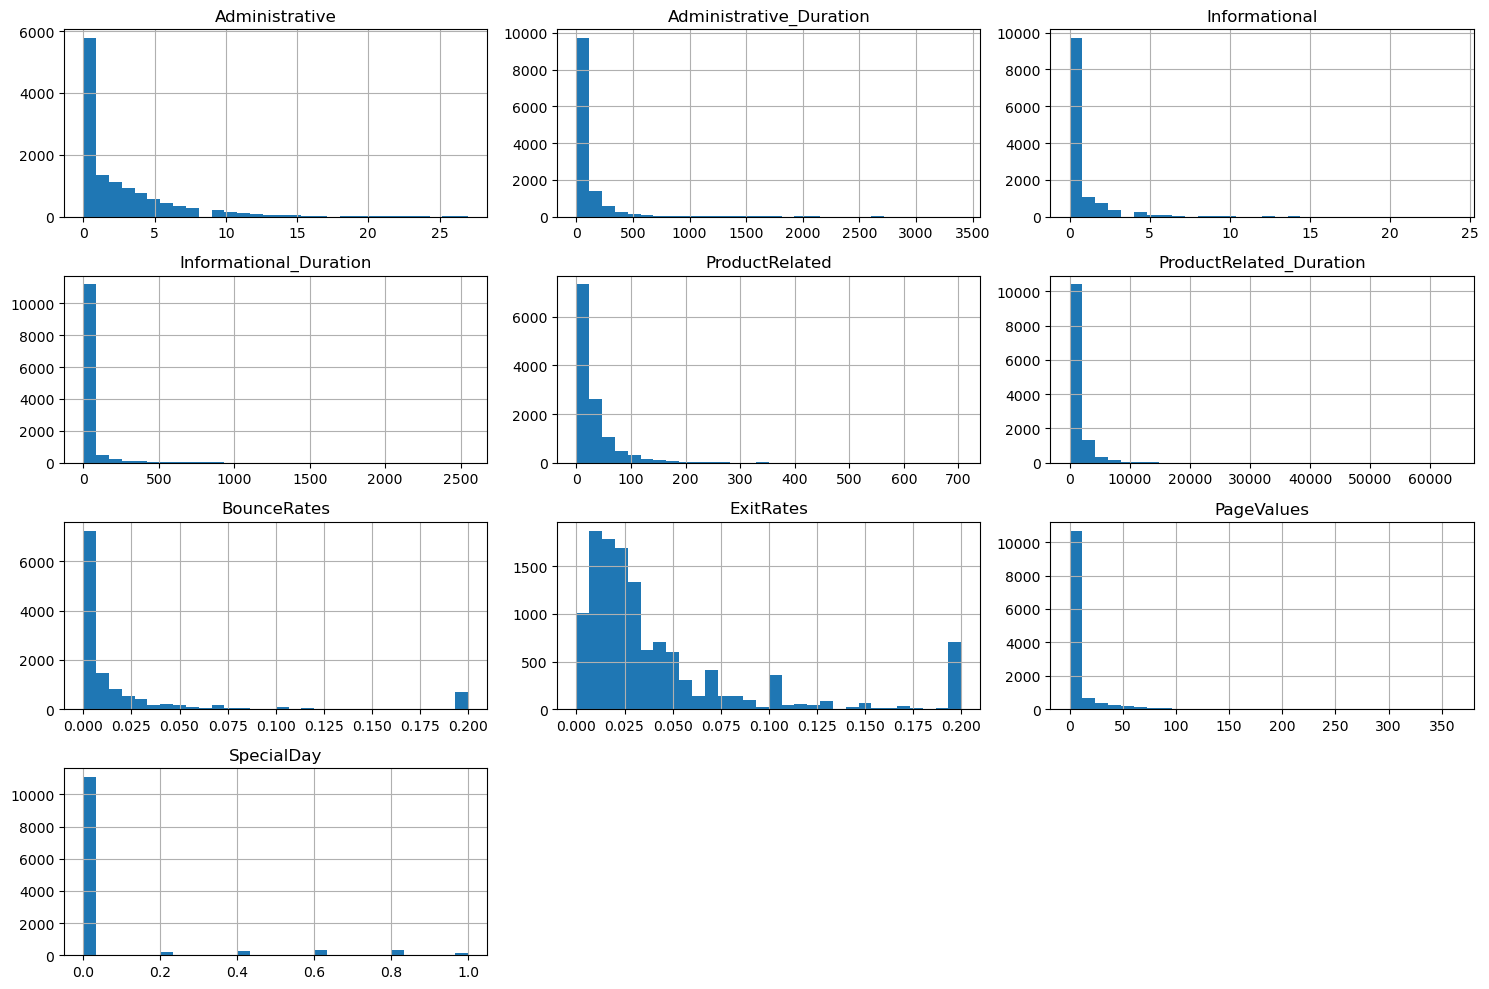

In [18]:
## Understanding distribution of features
numeric_cols = ['Administrative', 'Administrative_Duration', 'Informational',
                'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
                'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

df[numeric_cols].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

The histograms visually confirm the right skew quantified in 2.2, with sessions clustered near zero across every behavioural column and a long thin tail in each.

### 2.3.2 Understanding relationship between variables

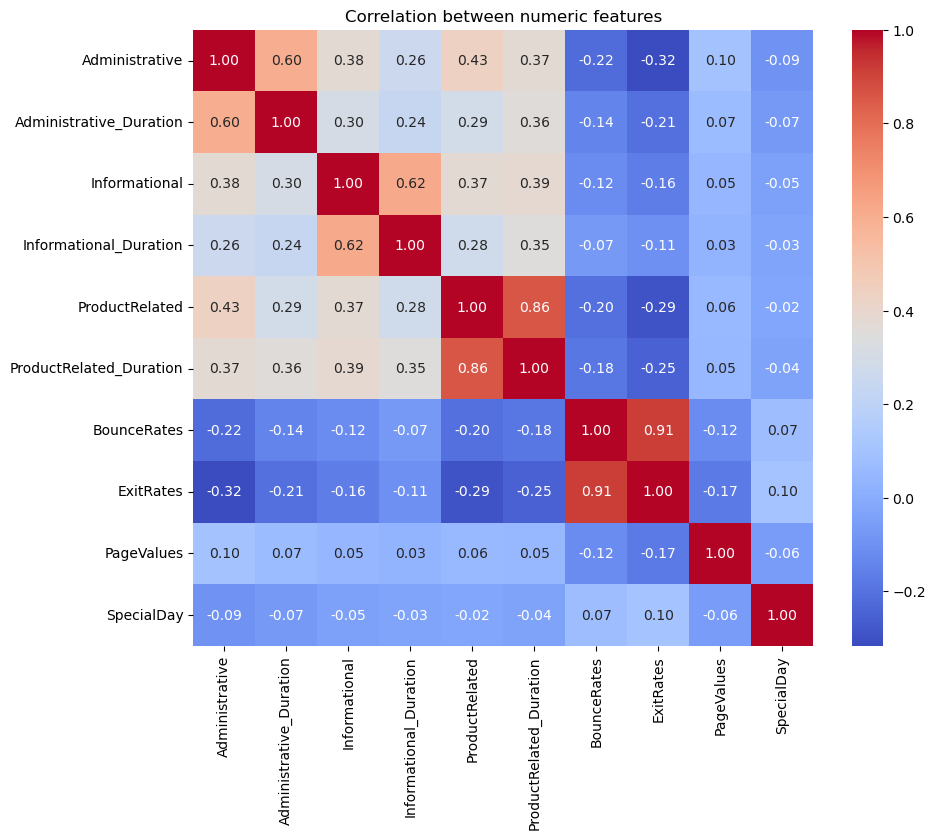

In [19]:
## Understanding relationship between variables
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation between numeric features')
plt.show()

Correlation between features. Two pairs stand out. ProductRelated and ProductRelated_Duration correlate at 0.86, a page count and the time spent on those pages, largely the same information twice. Rather than dropping either, this motivates a derived feature: average time per product page (ProductRelated_Duration / ProductRelated), which captures browsing intensity rather than volume. Forty pages in three minutes is skimming; four pages in three minutes is reading, and neither raw column tells those apart.

BounceRates and ExitRates correlate at 0.91, the highest in the matrix, and offer no equivalent opportunity, both measure a visitor leaving without engaging. For LogisticRegression this creates multicollinearity, making the individual coefficients unstable and unsafe to interpret. A bounce is a special case of an exit, so dropping BounceRates is defensible; both are kept here because tree models handle the redundancy and coefficient interpretation is not an objective.

The Administrative and Informational pairs are moderate (0.60 and 0.62),  related but not closely enough to drop. PageValues correlates weakly with everything (0.03–0.17 in absolute terms), so it carries information the browsing features don't. That is the first sign it will dominate feature importance, and the reason its availability during a live session needs establishing rather than assumed.

In [20]:
## PageValues by purchase outcome
df.groupby('Revenue')['PageValues'].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,1.975998,9.072424,0.0,0.000000,0.000000,0.000000,246.758590
True,1908.0,27.264518,35.191954,0.0,3.641144,16.758134,38.897742,361.763742


`PageValues` is the strongest predictor in the dataset and also the one requiring the most scrutiny, since the live-intervention framing in section 1 requires every feature to be available before the session ends. Google Analytics computes page value at page level as revenue and goal value attributed to a page divided by its unique pageviews, aggregated over a historical window. On that definition the session-level figure is the average across the pages viewed so far, and a live site could compute it mid-session by looking up pages already visited against a table refreshed from past data, since no part of the calculation requires the current session to have completed.

The distribution complicates that reading. At least three quarters of non-purchasing sessions have a value of exactly zero, which a page-level lookup alone cannot produce, since non-buyers browsing the same product pages as buyers would inherit the same non-zero values. The pattern is consistent instead with value accruing almost entirely to funnel pages (cart, checkout, payment), leaving the majority of the site at zero. Non-buyers who never reach the funnel therefore read as zero, while the roughly one quarter with non-zero values are those who reached checkout and abandoned. This also accounts for the small group of purchasing sessions at zero, which a strictly conversion-conditional metric could not produce.

The feature is therefore best understood as a proxy for funnel depth rather than a leaked outcome: it encodes whether the visitor has reached the pages that buyers typically reach. This is legitimately available in real time and legitimately predictive, but close to the target by construction, so the model's dependence on it is measured explicitly in section 5 rather than assumed.

# 3. Data Preparation

## 3.1 Data Cleaning

In [22]:
## Clean data
print(df['TrafficType'].value_counts())

TrafficType
2     3913
1     2451
3     2052
4     1069
13     738
10     450
6      444
8      343
5      260
11     247
20     198
9       42
7       40
15      38
19      17
14      13
18      10
16       3
12       1
17       1
Name: count, dtype: int64


TrafficType has 20 levels, but the counts fall off a cliff rather than tapering: the smallest levels worth keeping sit at 247 and 198 sessions, then the next level drops straight to 42 and keeps shrinking down to single-session levels (TrafficType 12 and 17 have one session each). One-hot encoding every level would create dummy columns with almost no positive rows, and a column with one row in it carries no signal a model can learn from.

So I grouped every level below that gap into a single "Other" bin. The cut is placed at the discontinuity the data already shows (198 down to 42), not at a round number chosen for tidiness: a threshold like 250 would look neater but would swallow the two genuine levels at 247 and 198 that have plenty of data to stand on their own. Folding only the nine sparse levels below the gap leaves "Other" at 165 sessions (~1.3% of the data), small but still trainable, and no longer a set of columns with a single observation each.

In [23]:
# The counts drop sharply from 198 to 42 sessions (see value_counts above),
# so we keep levels with at least 198 sessions and group the rest as "Other".
keep_threshold = 198
counts = df['TrafficType'].value_counts()

# Go through each session: if its TrafficType has enough sessions overall,
# keep the code (as text); otherwise label it "Other".
grouped = []
for level in df['TrafficType']:
    if counts[level] >= keep_threshold:
        grouped.append(str(level))
    else:
        grouped.append('Other')

# Add the grouped result as a new column
df['TrafficType_grouped'] = grouped

# Confirm: 11 real levels kept, sparse tail collapsed into one "Other" bin (165 sessions)
print(df['TrafficType_grouped'].value_counts())

TrafficType_grouped
2        3913
1        2451
3        2052
4        1069
13        738
10        450
6         444
8         343
5         260
11        247
20        198
Other     165
Name: count, dtype: int64


## 3.2 Feature Engineering

In [24]:
##Feature Engineering
def add_engineered_features(df):
    """Adds avg_time_per_product_page. Must be applied identically in streamlit_app.py."""
    df = df.copy()
    df['avg_time_per_product_page'] = (
        df['ProductRelated_Duration'] / df['ProductRelated'].replace(0, np.nan)
    ).fillna(0)
    return df
df = add_engineered_features(df)
# verify: no inf, no nan, and the 0-page sessions are 0
print(df['avg_time_per_product_page'].describe())
print("inf count:", np.isinf(df['avg_time_per_product_page']).sum())
print("nan count:", df['avg_time_per_product_page'].isna().sum())
print(df.loc[df['ProductRelated'] == 0, 'avg_time_per_product_page'].unique())

count    12330.000000
mean        37.633690
std         44.767916
min          0.000000
25%         17.613281
50%         28.878189
75%         45.084444
max       1411.000000
Name: avg_time_per_product_page, dtype: float64
inf count: 0
nan count: 0
[0.]


The ratio is also better behaved than the column it derives from: `ProductRelated_Duration` peaks at roughly 107 times its median, while the ratio peaks at about 49 times its median, because dividing by page count absorbs the very long sessions. The most extreme session in the raw column, 63,974 seconds across 449 product pages, becomes 142 seconds per page: still well above the ratio's median of 28.9 and around its 99th percentile, but no longer the single most extreme value in the column. This reduces the leverage concern raised in 2.2 without a log transform.

That session is nonetheless 17.8 hours long, which is more plausibly an abandoned tab or automated traffic than a real visitor, and the ratio's own maximum of 1,411 seconds on a single product page is the same pattern. These sessions are retained rather than capped or removed. They are genuine records rather than data errors, the ratio already compresses their influence considerably, and removing rows on the basis of implausibility requires a threshold that would be arbitrary. The tree-based model is the less affected of the two candidates, since splits depend only on value ordering, so the cost falls mainly on LogisticRegression; if the linear model underperforms, capping the duration columns at a high percentile is the first adjustment to try.

In [ ]:
##to check product related duration and avg time per product page
df.loc[df['ProductRelated_Duration'].idxmax(), ['ProductRelated', 'ProductRelated_Duration', 'avg_time_per_product_page']]

ProductRelated                       449
ProductRelated_Duration      63973.52223
avg_time_per_product_page     142.480005
Name: 8071, dtype: object

In [30]:
## One-hot encode categorical features
categorical_cols = ['TrafficType_grouped', 'OperatingSystems', 'Browser',
                    'Region', 'Month', 'VisitorType']
df_encoded = pd.get_dummies(df.drop(columns=['TrafficType']),
                            columns=categorical_cols,
                            drop_first=True)

print("before:", df.shape, "after:", df_encoded.shape)
print(df_encoded.dtypes.value_counts())
df_encoded.head()

before: (12330, 20) after: (12330, 62)
bool       51
float64     8
int64       3
Name: count, dtype: int64


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True



Why drop_first=True keeps only k−1 dummies.
For a categorical with k levels, k−1 dummy columns carry all the information: the omitted level is the one identified by every other dummy being False. Keep all k and each row's dummies sum to 1, which is perfectly collinear with the model's intercept. In LogisticRegression that reproduces the failure mode seen with BounceRates and ExitRates in 2.3.2, where the coefficients turn unstable and unsafe to interpret. Tree models are indifferent either way.

The encoding takes the frame from 20 columns to 62, of which 49 are dummies, 12 are the untouched numeric and boolean features, and one is the target. At 12,330 rows this is not a dimensionality problem, and the column that would have widened it most, TrafficType at 20 raw levels, was already binned down to 12 in 3.1. The widest categorical remaining is Browser at 13 levels, which is modest.

## 3.3 Train-Test Split

In [31]:
## Split data into train set and test set
# Separate features from target. Revenue is the outcome we predict.
X = df_encoded.drop(columns='Revenue')
y = df_encoded['Revenue']

# stratify=y holds the 15.47% buyer rate constant in both splits. Given the cost
# asymmetry in section 1, recall on buyers is the metric that matters, so the test
# set must contain a representative share of them for that recall to be stable.
# random_state=42 fixes the draw, so the PageValues dependence check in section 5
# is attributable to the model rather than to a luckier split.
# test_size=0.2 leaves 2,466 test sessions, ~382 of them buyers: enough positives
# for the minority-class metrics to be meaningful.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("train:", X_train.shape, "test:", X_test.shape)
print("train purchase rate:", y_train.mean().round(4))
print("test purchase rate:", y_test.mean().round(4))

train: (9864, 61) test: (2466, 61)
train purchase rate: 0.1547
test purchase rate: 0.1549


In [ ]:
## Initialise and train model
# Naive baseline: always predict the majority class (no purchase).
# Any real model must beat this to justify its existence.
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("=== Dummy (most_frequent) ===")
print(classification_report(y_test, y_pred_dummy, zero_division=0))


=== Dummy (most_frequent) ===
              precision    recall  f1-score   support

       False       0.85      1.00      0.92      2084
        True       0.00      0.00      0.00       382

    accuracy                           0.85      2466
   macro avg       0.42      0.50      0.46      2466
weighted avg       0.71      0.85      0.77      2466



In [33]:
# LogisticRegression needs scaled features (see 2.2). Scaler is fitted on train
# only, then applied to test, so no test information leaks into training.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)
y_pred_logreg = logreg.predict(X_test_scaled)

print("=== LogisticRegression ===")
print(classification_report(y_test, y_pred_logreg, zero_division=0))

# RandomForest is unaffected by scale, so it trains on the unscaled features.
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== RandomForest ===")
print(classification_report(y_test, y_pred_rf, zero_division=0))

=== LogisticRegression ===
              precision    recall  f1-score   support

       False       0.89      0.98      0.93      2084
        True       0.73      0.36      0.48       382

    accuracy                           0.88      2466
   macro avg       0.81      0.67      0.71      2466
weighted avg       0.87      0.88      0.86      2466

=== RandomForest ===
              precision    recall  f1-score   support

       False       0.91      0.97      0.94      2084
        True       0.74      0.51      0.60       382

    accuracy                           0.90      2466
   macro avg       0.83      0.74      0.77      2466
weighted avg       0.89      0.90      0.89      2466



# 4. Modelling

### 4.2 Train Model

# 5. Model Evaluation

In [ ]:
## Evaluate model


In [ ]:
## New data

## Predict


## Iterative model development


In [ ]:
## Further feature engineering / feature selection